In [ ]:
!pip install lpips
!pip install torchmetrics

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("xhlulu/140k-real-and-fake-faces")

print("Path to dataset files:", path)


from google.colab import drive
import os

print("Đang kết nối Google Drive...")
drive.mount('/content/drive')




Using Colab cache for faster access to the '140k-real-and-fake-faces' dataset.
Path to dataset files: /kaggle/input/140k-real-and-fake-faces
Đang kết nối Google Drive...
Mounted at /content/drive


In [ ]:
import os
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
#import lpips
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 0. CẤU HÌNH (CONFIG)
# ==============================================================================
class Config:
    # Đường dẫn dữ liệu
    TRAIN_REAL_DIR = "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train/real"
    VAL_REAL_DIR = "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/valid/real"

    # Đường dẫn lưu model
    DRIVE_PATH = "/content/drive/MyDrive/final/final1"
    SAVE_DIR = os.path.join(DRIVE_PATH, "qat_results_q6_10")

    # Tham số huấn luyện QAT (Fine-tuning)
    IMG_SIZE = 128
    BATCH_SIZE = 32
    NUM_EPOCHS = 10       # Chỉ cần train ngắn (5-10 epoch) để thích nghi
    LEARNING_RATE = 1e-5  # LR rất nhỏ để tinh chỉnh
    LEARNING_RATE_DISC = 1e-5
    BASE_CHANNEL = 32

    # Trọng số Loss
    LAMBDA_ADV = 0.05
    LAMBDA_SECRET = 5.0
    LAMBDA_COVER_L1 = 1.0
    LAMBDA_COVER_L2 = 1.0
    LAMBDA_COVER_LPIPS = 1.0

    # Thiết bị
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(Config.SAVE_DIR, exist_ok=True)
print(f"Cấu hình QAT đã sẵn sàng. Thiết bị: {Config.DEVICE}")

# ==============================================================================
# 1. CORE QUANTIZATION (Q6.10)
# ==============================================================================
class FakeQuantizeQ6_10(torch.autograd.Function):
    """
    Q6.10 Format:
    - Scale: 1024 (2^10)
    - Range: [-32768, 32767] (Tương ứng [-32.0, 31.999] trong thực tế)
    """
    @staticmethod
    def forward(ctx, x):
        scale = 1024.0
        # Nhân scale -> Làm tròn -> Kẹp giới hạn 16-bit -> Chia scale
        return torch.round(x * scale).clamp(-32768, 32767) / scale

    @staticmethod
    def backward(ctx, grad_output):
        # STE: Cho gradient đi qua nguyên vẹn
        return grad_output

def qat_quant(x):
    return FakeQuantizeQ6_10.apply(x)

class QuantIdentity(nn.Module):
    """Layer dùng để chèn qat_quant vào nn.Sequential"""
    def forward(self, x):
        return qat_quant(x)

# ==============================================================================
# 2. QAT BLOCKS (WEIGHTS & ACTIVATIONS)
# ==============================================================================

class QATSeparableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        # Giữ nguyên tên biến để load được weights cũ
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size, stride, padding, groups=in_channels, bias=False)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)

    def forward(self, x):
        # 1. Quantize Weights trước khi Conv
        w_dw = qat_quant(self.depthwise.weight)
        w_pw = qat_quant(self.pointwise.weight)

        # 2. Depthwise Conv
        x = F.conv2d(x, w_dw, self.depthwise.bias, self.depthwise.stride,
                     self.depthwise.padding, self.depthwise.dilation, self.depthwise.groups)

        # (Option) Quantize output trung gian (Depthwise Out)
        x = qat_quant(x)

        # 3. Pointwise Conv
        x = F.conv2d(x, w_pw, self.pointwise.bias, self.pointwise.stride,
                     self.pointwise.padding, self.pointwise.dilation, self.pointwise.groups)
        return x

class QATEncoder(nn.Module):
    def __init__(self, base_c=32):
        super().__init__()

        def qat_conv_block(in_c, out_c, stride=1):
            return nn.Sequential(
                QATSeparableConv2d(in_c, out_c, stride=stride),
                nn.BatchNorm2d(out_c),
                nn.ReLU(True),
                QuantIdentity() # Quantize Activations sau ReLU
            )

        self.head = qat_conv_block(6, base_c)
        self.down1 = qat_conv_block(base_c, base_c*2, stride=2)
        self.down2 = qat_conv_block(base_c*2, base_c*4, stride=2)
        self.bottleneck = qat_conv_block(base_c*4, base_c*8, stride=2)

        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')
        self.up1 = qat_conv_block(base_c*8 + base_c*4, base_c*4)
        self.up2 = qat_conv_block(base_c*4 + base_c*2, base_c*2)
        self.up3 = qat_conv_block(base_c*2 + base_c, base_c)

        # Layer cuối dùng Conv thường (Pointwise)
        self.tail_conv = nn.Conv2d(base_c, 3, kernel_size=1, bias=False)
        self.tanh = nn.Tanh()

    def forward(self, x_cover, x_secret):
        # QUAN TRỌNG: Quantize Input (giả lập ảnh 16-bit vào FPGA)
        x_cover = qat_quant(x_cover)
        x_secret = qat_quant(x_secret)

        x = torch.cat([x_cover, x_secret], dim=1)
        c1 = self.head(x)
        c2 = self.down1(c1)
        c3 = self.down2(c2)
        b  = self.bottleneck(c3)

        u1 = self.up1(torch.cat([self.upsample(b), c3], dim=1))
        u2 = self.up2(torch.cat([self.upsample(u1), c2], dim=1))
        u3 = self.up3(torch.cat([self.upsample(u2), c1], dim=1))

        # Quantize weight lớp cuối
        w_tail = qat_quant(self.tail_conv.weight)
        out = F.conv2d(u3, w_tail, stride=1)

        # Quantize Output của mạng (trước khi cộng residual)
        out = qat_quant(self.tanh(out))

        return torch.clamp(x_cover + out, -1, 1)

class QATDecoder(nn.Module):
    def __init__(self, base_c=32):
        super().__init__()

        def qat_conv_block(in_c, out_c, stride=1, kernel=3, padding=1):
             return nn.Sequential(
                      QATSeparableConv2d(in_c, out_c, kernel_size=kernel, stride=stride, padding=padding),
                      nn.BatchNorm2d(out_c),
                      nn.ReLU(True),
                      QuantIdentity() # Quantize Activations
            )

        self.head = qat_conv_block(3, base_c)
        self.down1 = qat_conv_block(base_c, base_c*2, stride=2)
        self.down2 = qat_conv_block(base_c*2, base_c*4, stride=2)
        self.down3 = qat_conv_block(base_c*4, base_c*8, stride=2)
        self.down4 = qat_conv_block(base_c*8, base_c*16, stride=2)
        self.bottleneck = qat_conv_block(base_c*16, base_c*32, stride=2)

        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

        self.up1 = qat_conv_block(base_c*32 + base_c*16, base_c*16)
        self.up2 = qat_conv_block(base_c*16 + base_c*8, base_c*8)
        self.up3 = qat_conv_block(base_c*8 + base_c*4, base_c*4)
        self.up4 = qat_conv_block(base_c*4 + base_c*2, base_c*2)
        self.up5 = qat_conv_block(base_c*2 + base_c, base_c)

        self.tail_conv = nn.Conv2d(base_c, 3, kernel_size=1, bias=True)
        self.tanh = nn.Tanh()

    def forward(self, x_stego):
        # Quantize Input cho Decoder
        x_stego = qat_quant(x_stego)

        c1 = self.head(x_stego)
        c2 = self.down1(c1)
        c3 = self.down2(c2)
        c4 = self.down3(c3)
        c5 = self.down4(c4)
        b  = self.bottleneck(c5)

        u1 = self.up1(torch.cat([self.upsample(b), c5], dim=1))
        u2 = self.up2(torch.cat([self.upsample(u1), c4], dim=1))
        u3 = self.up3(torch.cat([self.upsample(u2), c3], dim=1))
        u4 = self.up4(torch.cat([self.upsample(u3), c2], dim=1))
        u5 = self.up5(torch.cat([self.upsample(u4), c1], dim=1))

        # Quantize Weight & Bias lớp cuối
        w_tail = qat_quant(self.tail_conv.weight)
        b_tail = qat_quant(self.tail_conv.bias)
        out = F.conv2d(u5, w_tail, b_tail, stride=1)

        return self.tanh(out) # Output cuối cùng có thể không cần quantize nếu chỉ để view

# ==============================================================================
# 3. DISCRIMINATOR (FLOAT32 - GIỮ NGUYÊN)
# ==============================================================================
# Chúng ta giữ nguyên Discriminator ở Float32 để nó "chấm thi" khó nhất có thể.

class Type1ResBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, 1, 1, bias=False), nn.BatchNorm2d(out_c), nn.ReLU(True),
            nn.Conv2d(out_c, out_c, 3, 1, 1, bias=False), nn.BatchNorm2d(out_c)
        )
        self.shortcut = nn.Sequential()
        if in_c != out_c: self.shortcut = nn.Conv2d(in_c, out_c, 1, 1, 0, bias=False)
    def forward(self, x): return x + self.conv(x)

class Type2ResBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, 1, 1, bias=False), nn.BatchNorm2d(out_c), nn.ReLU(True),
            nn.Conv2d(out_c, out_c, 3, 1, 1, bias=False), nn.BatchNorm2d(out_c), nn.AvgPool2d(3, 2, 1)
        )
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_c, out_c, 1, 1, 0, bias=False), nn.BatchNorm2d(out_c), nn.AvgPool2d(3, 2, 1)
        )
    def forward(self, x): return self.shortcut(x) + self.conv(x)

class Type3Block(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, 1, 1, bias=False), nn.BatchNorm2d(out_c), nn.ReLU(True), nn.AvgPool2d(3, 2, 1)
        )
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_c, out_c, 1, 1, 0, bias=False), nn.BatchNorm2d(out_c), nn.AvgPool2d(3, 2, 1)
        )
    def forward(self, x): return self.shortcut(x) + self.conv(x)

class SRNetDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Conv2d(3, 16, 3, 1, 1, bias=False)
        self.layer2 = Type1ResBlock(16, 16)
        self.layer3 = Type2ResBlock(16, 32)
        self.layer4 = Type2ResBlock(32, 64)
        self.layer5 = Type2ResBlock(64, 64)
        self.layer6 = Type3Block(64, 64)
        self.fc = nn.Linear(64, 1)
    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = self.layer6(x)
        x = x.mean(dim=[2, 3])
        return self.fc(x)


Cấu hình QAT đã sẵn sàng. Thiết bị: cpu


In [ ]:

# ==============================================================================
# 4. DATA & UTILS
# ==============================================================================
from torchmetrics.image.psnr import PeakSignalNoiseRatio
from torchmetrics.image.ssim import StructuralSimilarityIndexMeasure

class RealImageDataset(Dataset):
    def __init__(self, real_dir, img_size=128):
        try: self.paths = [os.path.join(real_dir, f) for f in os.listdir(real_dir) if f.lower().endswith(('png','jpg','jpeg'))]
        except: self.paths = []
        self.t = transforms.Compose([transforms.Resize((img_size, img_size)), transforms.ToTensor(), transforms.Normalize([0.5]*3,[0.5]*3)])
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        try: return self.t(Image.open(self.paths[i]).convert("RGB"))
        except: return torch.zeros(3, 128, 128)

def get_loaders(cfg):
    dl_train = DataLoader(RealImageDataset(cfg.TRAIN_REAL_DIR, cfg.IMG_SIZE), batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
    dl_val = DataLoader(RealImageDataset(cfg.VAL_REAL_DIR, cfg.IMG_SIZE), batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=2, drop_last=True)
    return dl_train, dl_val

psnr_fn = PeakSignalNoiseRatio(data_range=1.0).to(Config.DEVICE)
ssim_fn = StructuralSimilarityIndexMeasure(data_range=1.0).to(Config.DEVICE)

def calc_metrics(i1, i2):
    i1, i2 = ((i1+1)/2).clamp(0,1), ((i2+1)/2).clamp(0,1)
    return psnr_fn(i1, i2).item(), ssim_fn(i1, i2).item()

def denorm(t): return ((t+1)/2).clamp(0,1).cpu().permute(0,2,3,1).numpy()

def train_step(models, optims, losses, data, cfg):
    enc, dec, disc = models
    opt_G, opt_D = optims
    l1, l2, bce, lpips_fn = losses
    cover, secret = data

    # --- Train D (Float32) ---
    opt_D.zero_grad()
    pred_real = disc(cover)
    loss_real = bce(pred_real, torch.ones_like(pred_real) * 0.9)

    with torch.no_grad(): stego = enc(cover, secret) # Encoder tạo ảnh Stego (bị nhiễu Q6.10)
    pred_stego = disc(stego)
    loss_stego = bce(pred_stego, torch.zeros_like(pred_stego))

    loss_D = (loss_real + loss_stego) * 0.5
    loss_D.backward(); opt_D.step()

    with torch.no_grad():
        d_acc = ((torch.sigmoid(pred_real)>0.5).float().mean() + (torch.sigmoid(pred_stego)<0.5).float().mean()) / 2

    # --- Train G (QAT Models) ---
    opt_G.zero_grad()
    stego = enc(cover, secret)
    rev = dec(stego)

    l_c = cfg.LAMBDA_COVER_L1*l1(stego, cover) + cfg.LAMBDA_COVER_L2*l2(stego, cover) + cfg.LAMBDA_COVER_LPIPS*lpips_fn(stego, cover).mean()
    l_s = cfg.LAMBDA_SECRET * l1(rev, secret)
    l_adv = cfg.LAMBDA_ADV * bce(disc(stego), torch.ones_like(pred_stego))

    loss_G = l_c + l_s + l_adv
    loss_G.backward(); opt_G.step()

    return loss_D.item(), {'Loss_G': loss_G.item(), 'Cov': l_c.item(), 'Sec': l_s.item(), 'Adv': l_adv.item(), 'D_Acc': d_acc.item()}

def run_validation(models, loader, cfg, epoch):
    enc, dec, disc = models
    enc.eval(); dec.eval()
    acc = {'Cov':0, 'Sec':0, 'PSNR_C':0, 'SSIM_C':0, 'PSNR_S':0, 'SSIM_S':0}
    cnt = 0
    with torch.no_grad():
        for cover in loader:
            cover = cover.to(cfg.DEVICE)
            secret = cover[torch.randperm(cover.size(0))].to(cfg.DEVICE)
            stego = enc(cover, secret)
            rev = dec(stego)

            acc['Cov'] += nn.L1Loss()(stego, cover).item()
            acc['Sec'] += nn.L1Loss()(rev, secret).item()
            pc, sc = calc_metrics(stego, cover)
            ps, ss = calc_metrics(rev, secret)
            acc['PSNR_C'] += pc; acc['SSIM_C'] += sc
            acc['PSNR_S'] += ps; acc['SSIM_S'] += ss
            cnt += 1

    res = {k: v/cnt for k, v in acc.items()}

    # Visualization
    c = next(iter(loader)).to(cfg.DEVICE)[:3]
    s = c[torch.randperm(c.size(0))].to(cfg.DEVICE)
    with torch.no_grad():
        st, re = enc(c, s), dec(enc(c, s))
        diff = torch.abs(st - c)
        diff = (diff - diff.min()) / (diff.max() - diff.min() + 1e-8)

    imgs = [denorm(c), denorm(s), denorm(st), denorm(diff), denorm(re)]
    titles = ["Cover", "Secret", "Stego", "Residual", "Revealed"]
    fig, axes = plt.subplots(3, 5, figsize=(15, 9))
    for i in range(3):
        for j in range(5):
            img_show = imgs[j][i]
            if j == 3: img_show = img_show.mean(2)
            axes[i,j].imshow(img_show, cmap='inferno' if j==3 else None)
            if i==0: axes[i,j].set_title(titles[j])
            axes[i,j].axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(cfg.SAVE_DIR, f"qat_vis_epoch_{epoch}.png"))
    plt.close()
    return res

def plot_training_history(history, cfg, epoch):
    if len(history['val_psnr_c']) == 0: return
    ep_range = range(1, len(history['train_loss_g']) + 1)
    if len(ep_range) != len(history['val_psnr_c']):
        min_len = min(len(ep_range), len(history['val_psnr_c']))
        ep_range = range(1, min_len + 1)

    fig, ax = plt.subplots(2, 3, figsize=(20, 10))
    fig.suptitle(f'QAT Training Progress - Epoch {epoch}', fontsize=16)

    ax[0,0].plot(ep_range, history['train_loss_g'][:len(ep_range)], label='G', color='b')
    ax[0,0].plot(ep_range, history['train_loss_d'][:len(ep_range)], label='D', color='r')
    ax[0,0].legend(); ax[0,0].set_title('Losses')

    ax[0,1].plot(ep_range, history['train_cov'][:len(ep_range)], label='Cov')
    ax[0,1].plot(ep_range, history['train_sec'][:len(ep_range)], label='Sec')
    ax[0,1].legend(); ax[0,1].set_title('G Components')

    ax[0,2].plot(ep_range, history['train_d_acc'][:len(ep_range)], label='D Acc')
    ax[0,2].set_title('D Accuracy')

    ax[1,0].plot(ep_range, history['val_psnr_c'][:len(ep_range)], label='Cov')
    ax[1,0].plot(ep_range, history['val_psnr_s'][:len(ep_range)], label='Sec')
    ax[1,0].set_title('PSNR')

    ax[1,1].plot(ep_range, history['val_ssim_c'][:len(ep_range)], label='Cov')
    ax[1,1].plot(ep_range, history['val_ssim_s'][:len(ep_range)], label='Sec')
    ax[1,1].set_title('SSIM')

    plt.tight_layout()
    plt.savefig(os.path.join(cfg.SAVE_DIR, "qat_history.png"))
    plt.close()

# ==============================================================================
# 5. MAIN PROGRAM (FINE-TUNING)
# ==============================================================================
def main():
    cfg = Config()
    dl_train, dl_val = get_loaders(cfg)
    if len(dl_train) == 0: return print("Lỗi Data")

    # 1. Khởi tạo QAT Models
    print("Khởi tạo QATEncoder và QATDecoder (Q6.10)...")
    enc_qat = QATEncoder(base_c=cfg.BASE_CHANNEL).to(cfg.DEVICE)
    dec_qat = QATDecoder(base_c=cfg.BASE_CHANNEL).to(cfg.DEVICE)

    # Discriminator giữ nguyên Float32
    disc = SRNetDiscriminator().to(cfg.DEVICE)

    # 2. LOAD PRETRAINED WEIGHTS (QUAN TRỌNG)
    print("Loading Pretrained Float32 Weights...")
    try:
        # Load weights cũ vào cấu trúc mới
        # Do tên biến self.depthwise, self.pointwise giống hệt nhau nên load được
        # strict=False để bỏ qua các lớp QuantIdentity không có tham số
        enc_qat.load_state_dict(torch.load(os.path.join(cfg.DRIVE_PATH, "best_enc.pth")), strict=False)
        dec_qat.load_state_dict(torch.load(os.path.join(cfg.DRIVE_PATH, "best_dec.pth")), strict=False)

        # Load Discriminator (nếu có file checkpoint chung, không thì khởi tạo lại cũng được)
        ckpt_path = os.path.join(cfg.DRIVE_PATH, "checkpoint.pth")
        if os.path.exists(ckpt_path):
            c = torch.load(ckpt_path)
            disc.load_state_dict(c['disc'])
            print("Loaded Discriminator checkpoint.")
        else:
            print("Không tìm thấy Discriminator checkpoint, train D từ đầu.")

    except Exception as e:
        print(f"Lỗi load weights: {e}")
        print("DỪNG LẠI! QAT cần pretrained weights để hội tụ.")
        return

    # 3. Optimizers với Learning Rate THẤP
    opt_G = optim.Adam(list(enc_qat.parameters())+list(dec_qat.parameters()), lr=cfg.LEARNING_RATE, betas=(0.5, 0.999))
    opt_D = optim.Adam(disc.parameters(), lr=cfg.LEARNING_RATE_DISC, betas=(0.5, 0.999))
    losses = [nn.L1Loss(), nn.MSELoss(), nn.BCEWithLogitsLoss(), lpips.LPIPS(net='alex').to(cfg.DEVICE)]

    history = {'train_loss_g': [], 'train_loss_d': [], 'train_cov': [], 'train_sec': [], 'train_adv': [], 'train_d_acc': [],
               'val_psnr_c': [], 'val_ssim_c': [], 'val_psnr_s': [], 'val_ssim_s': []}

    best_score = float('inf')

    print(f"\n BẮT ĐẦU QAT FINE-TUNING (Epoch 1 -> {cfg.NUM_EPOCHS})")

    for epoch in range(1, cfg.NUM_EPOCHS + 1):
        # Bật chế độ Train (để FakeQuantize hoạt động)
        enc_qat.train(); dec_qat.train(); disc.train()

        t0 = time.time()
        running_results = {'Loss_D': 0, 'Loss_G': 0, 'Cov': 0, 'Sec': 0, 'Adv': 0, 'D_Acc': 0}

        for idx, cover in enumerate(dl_train):
            cover = cover.to(cfg.DEVICE)
            secret = cover[torch.randperm(cover.size(0))].to(cfg.DEVICE)

            # Train Step (Input sẽ tự động được Quantize trong Forward của Encoder)
            l_d, m = train_step((enc_qat, dec_qat, disc), (opt_G, opt_D), losses, (cover, secret), cfg)

            running_results['Loss_D'] += l_d
            for k, v in m.items(): running_results[k] += v

            if idx % 100 == 0:
                print(f"QAT Ep{epoch} B{idx}: Loss_G={m['Loss_G']:.3f} | Cov={m['Cov']:.3f}")

        # Log History
        for k in running_results: running_results[k] /= len(dl_train)
        history['train_loss_g'].append(running_results['Loss_G'])
        history['train_loss_d'].append(running_results['Loss_D'])
        history['train_cov'].append(running_results['Cov'])
        history['train_sec'].append(running_results['Sec'])
        history['train_adv'].append(running_results['Adv'])
        history['train_d_acc'].append(running_results['D_Acc'])

        # Validation
        print(f">>> Validating QAT...")
        res = run_validation((enc_qat, dec_qat, disc), dl_val, cfg, epoch)

        history['val_psnr_c'].append(res['PSNR_C'])
        history['val_ssim_c'].append(res['SSIM_C'])
        history['val_psnr_s'].append(res['PSNR_S'])
        history['val_ssim_s'].append(res['SSIM_S'])

        score = res['Cov'] + res['Sec']
        print(f"    [QAT VAL] Score: {score:.4f} | Cov PSNR: {res['PSNR_C']:.2f} | Sec PSNR: {res['PSNR_S']:.2f}")

        plot_training_history(history, cfg, epoch)


        save_dict = {
            'epoch': epoch,
            'enc': enc_qat.state_dict(),
            'dec': dec_qat.state_dict(),
            'disc': disc.state_dict(),
            'hist': history
        }
        torch.save(save_dict, os.path.join(Config.SAVE_DIR, "qat_checkpoint.pth"))

        # Save Checkpoint QAT
        if score < best_score:
            print("NEW QAT BEST! Saving...")
            best_score = score
            torch.save(enc_qat.state_dict(), os.path.join(cfg.SAVE_DIR, "best_enc_qat_q6_10.pth"))
            torch.save(dec_qat.state_dict(), os.path.join(cfg.SAVE_DIR, "best_dec_qat_q6_10.pth"))

        print(f"--- Done Epoch {epoch} ({time.time()-t0:.1f}s) ---\n")

        # 3. Lưu ảnh Visualization (Để so sánh chất lượng mắt nhìn)
        # Tên file sẽ là: qat_vis_epoch_1.png, qat_vis_epoch_2.png...
        plt.savefig(os.path.join(Config.SAVE_DIR, f"qat_vis_epoch_{epoch}.png"))

        # 4. Lưu đồ thị History (Loss/PSNR/SSIM)
        plt.savefig(os.path.join(Config.SAVE_DIR, "qat_training_history.png"))

if __name__ == "__main__":
    main()

ModuleNotFoundError: No module named 'lpips'

✅ Đã load thành công Encoder & Decoder QAT 16-bit.


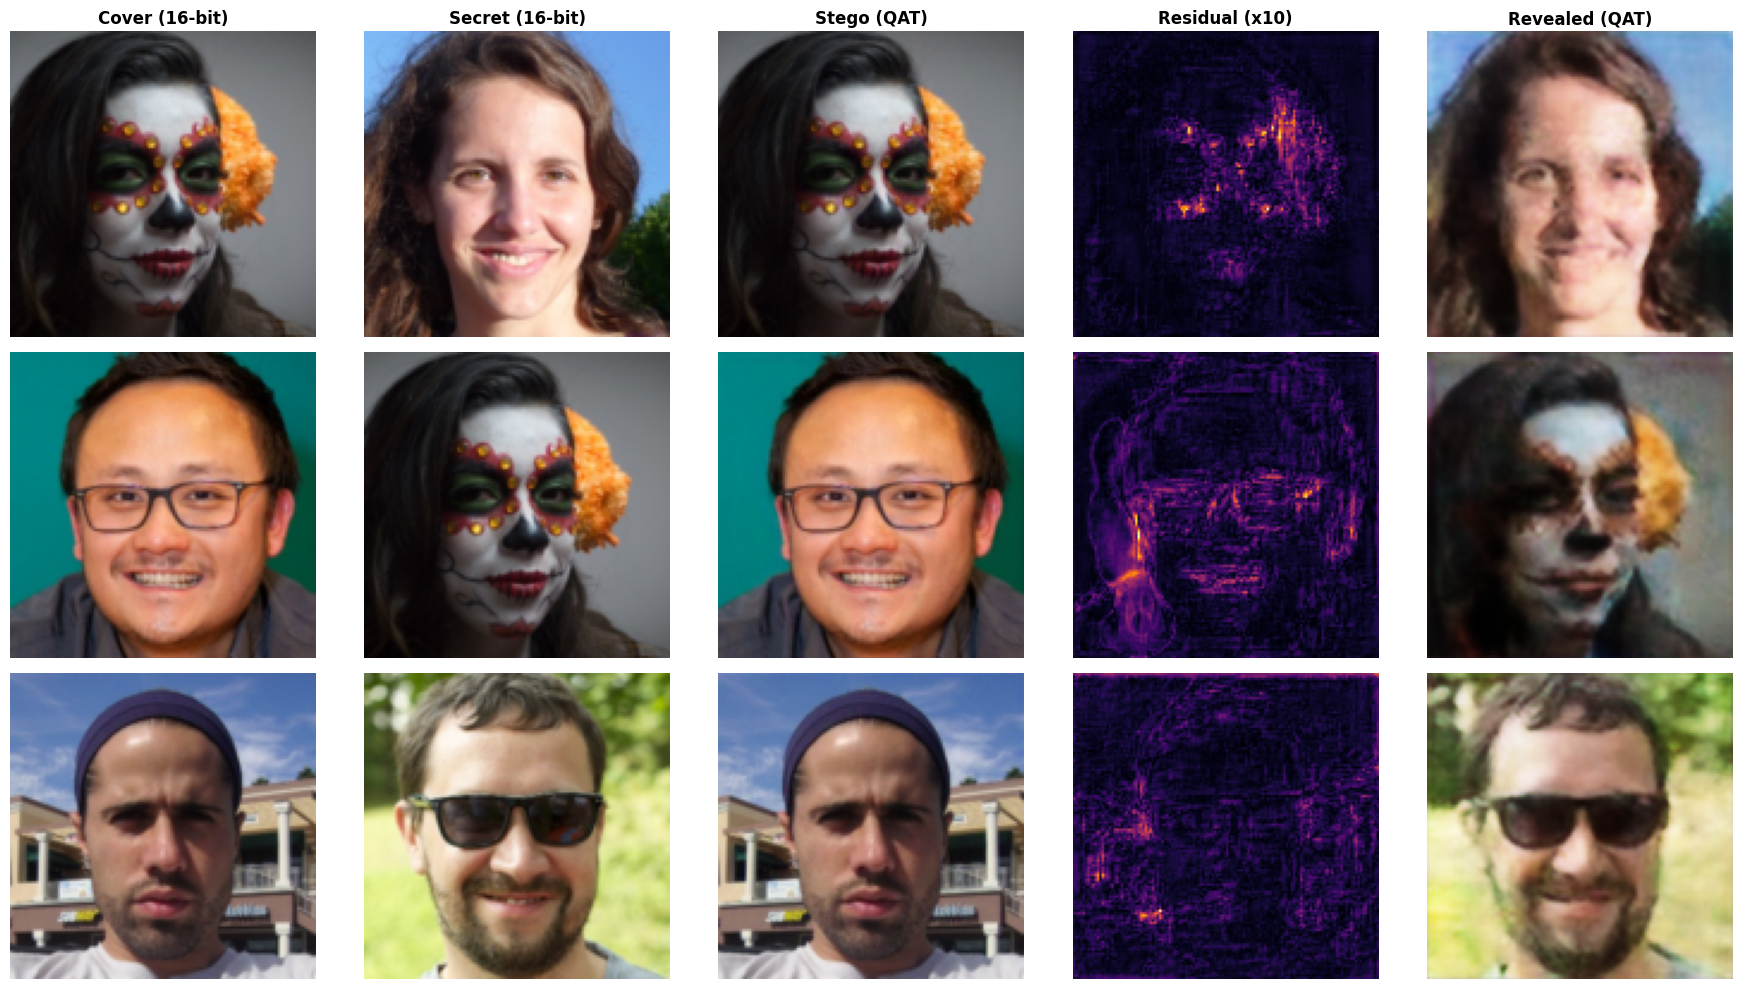

 Đã lưu ảnh so sánh tại: /content/drive/MyDrive/final/final1/qat_results_q6_10/final_qat_comparison.png


In [ ]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
import os
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# 1. THIẾT LẬP ĐƯỜNG DẪN & CONFIG
# ==============================================================================

QAT_DIR = "/content/drive/MyDrive/final/final1/qat_results_q6_10"
ENC_QAT_PATH = os.path.join(QAT_DIR, "best_enc_qat_q6_10.pth")
DEC_QAT_PATH = os.path.join(QAT_DIR, "best_dec_qat_q6_10.pth")
OUTPUT_IMAGE_PATH = os.path.join(QAT_DIR, "final_qat_comparison.png")

# Đảm bảo dùng đúng thiết bị
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==============================================================================
# 2. LOAD LẠI CẤU TRÚC MODEL QAT (Bắt buộc phải giống lúc train)
# ==============================================================================
# Lưu ý: Bạn cần đảm bảo các lớp FakeQuantizeQ6_10, QATSeparableConv2d,
# QATEncoder, QATDecoder đã được định nghĩa ở các ô trước đó.

def load_qat_models():
    enc = QATEncoder(base_c=32).to(device)
    dec = QATDecoder(base_c=32).to(device)

    # Load trọng số
    enc.load_state_dict(torch.load(ENC_QAT_PATH, map_location=device))
    dec.load_state_dict(torch.load(DEC_QAT_PATH, map_location=device))

    enc.eval()
    dec.eval()
    print("✅ Đã load thành công Encoder & Decoder QAT 16-bit.")
    return enc, dec

# ==============================================================================
# 3. HÀM XỬ LÝ ẢNH & INFERENCE
# ==============================================================================
def denormalize(t):
    return ((t + 1) / 2).clamp(0, 1).cpu().permute(0, 2, 3, 1).numpy()

def generate_comparison_images(enc, dec, num_samples=3):
    # Lấy dữ liệu từ Val Loader (hoặc tạo giả lập nếu không có loader)
    cfg = Config()
    _, dl_val = get_loaders(cfg)
    cover_batch = next(iter(dl_val)).to(device)
    # Tạo secret bằng cách xáo trộn batch
    secret_batch = cover_batch[torch.randperm(cover_batch.size(0))].to(device)

    with torch.no_grad():
        # Bước cực kỳ quan trọng: Mô phỏng ảnh đầu vào 16-bit Q6.10
        # Mặc dù trong forward của model đã có, ta thực hiện ở đây để tường minh
        c = qat_quant(cover_batch[:num_samples])
        s = qat_quant(secret_batch[:num_samples])

        # Chạy model
        stego = enc(c, s)
        revealed = dec(stego)

        # Tính sai số (Residual) - Nhân 10 để nhìn rõ hơn
        residual = torch.abs(stego - c)
        residual = (residual - residual.min()) / (residual.max() - residual.min() + 1e-8)

    # Chuyển đổi về numpy để vẽ
    c_np = denormalize(c)
    s_np = denormalize(s)
    st_np = denormalize(stego)
    res_np = denormalize(residual)
    rev_np = denormalize(revealed)

    # Vẽ biểu đồ so sánh
    titles = ["Cover", "Secret", "Stego (QAT)", "Residual (x10)", "Revealed (QAT)"]
    fig, axes = plt.subplots(num_samples, 5, figsize=(18, 10))

    for i in range(num_samples):
        imgs = [c_np[i], s_np[i], st_np[i], res_np[i], rev_np[i]]
        for j in range(5):
            ax = axes[i, j]
            if j == 3: # Residual vẽ Heatmap cho dễ nhìn
                ax.imshow(imgs[j].mean(axis=2), cmap='inferno')
            else:
                ax.imshow(imgs[j])

            if i == 0:
                ax.set_title(titles[j], fontweight='bold', fontsize=12)
            ax.axis('off')

    plt.tight_layout()
    plt.savefig(OUTPUT_IMAGE_PATH)
    plt.show()
    print(f" Đã lưu ảnh so sánh tại: {OUTPUT_IMAGE_PATH}")

# Thực thi
enc_qat, dec_qat = load_qat_models()
generate_comparison_images(enc_qat, dec_qat)

In [ ]:
import os
import shutil
from google.colab import drive

# 1. Thử unmount trước để an toàn
try:
    drive.flush_and_unmount()
    print("Đã unmount thành công.")
except Exception as e:
    print(f"Chưa mount hoặc lỗi unmount: {e}")

# 2. Xóa thư mục /content/drive nếu nó đang tồn tại và chứa file rác
if os.path.exists('/content/drive'):
    print("Phát hiện thư mục cũ, đang xóa...")
    shutil.rmtree('/content/drive')

# 3. Mount lại với tham số force_remount
print("Đang kết nối lại Google Drive...")
drive.mount('/content/drive', force_remount=True)

Drive not mounted, so nothing to flush and unmount.
Đã unmount thành công.
Phát hiện thư mục cũ, đang xóa...
Đang kết nối lại Google Drive...
Mounted at /content/drive


In [ ]:
import torch
import numpy as np
import os


# ==============================================================================
# 1. CẤU HÌNH ĐƯỜNG DẪN
# ==============================================================================
# Đường dẫn chứa file model đã train xong
INPUT_MODEL_PATH = "/content/drive/MyDrive/final/final1/qat_results_q6_10/best_enc_qat_q6_10.pth"

# Thư mục chứa các file .mem sẽ xuất ra
OUTPUT_HEX_DIR = "/content/drive/MyDrive/final/final1/qat_results_q6_10/fpga_hex_files"
os.makedirs(OUTPUT_HEX_DIR, exist_ok=True)

# ==============================================================================
# 2. HÀM CHUYỂN ĐỔI & GHI FILE HEX
# ==============================================================================
def export_tensor_to_hex(tensor_name, tensor_data, output_dir):
    """
    Input:
       - tensor_name: Tên lớp (ví dụ: head.0.depthwise.weight)
       - tensor_data: Dữ liệu Float32
    Output:
       - File .mem chứa mã Hex Q6.10
    """
    # 1. Chuyển sang Numpy
    data_float = tensor_data.detach().cpu().numpy()

    # 2. Toán tử Q6.10: Nhân 1024 và làm tròn
    # Ép sang int16 để mô phỏng đúng giới hạn lưu trữ
    data_int16 = np.round(data_float * 1024).astype(np.int16)

    # 3. Tạo tên file an toàn
    safe_name = tensor_name.replace(".", "_") + ".mem"
    file_path = os.path.join(output_dir, safe_name)

    # 4. Ghi file Hex
    with open(file_path, "w") as f:
        for val in data_int16.flatten():
            val_python = int(val)
            f.write(f"{val_python & 0xFFFF:04x}\n")

    print(f"   Saved: {safe_name} \t(Size: {data_int16.size})")

# ==============================================================================
# 3. CHƯƠNG TRÌNH CHÍNH
# ==============================================================================
def main_export():
    device = torch.device("cpu") # Xuất file thì dùng CPU cho đơn giản

    print(f"--- BẮT ĐẦU XUẤT FILE HEX Q6.10 ---")
    print(f"Input: {INPUT_MODEL_PATH}")
    print(f"Output: {OUTPUT_HEX_DIR}\n")

    # B1: Khởi tạo lại Model (Cần class QATEncoder đã định nghĩa ở các cell trước)
    try:
        model = QATEncoder(base_c=32).to(device)
    except NameError:
        print("LỖI: chưa chạy cell định nghĩa class 'QATEncoder'.")
        return

    # B2: Load trọng số từ file .pth
    if not os.path.exists(INPUT_MODEL_PATH):
        print(f"LỖI: Không tìm thấy file {INPUT_MODEL_PATH}")
        return

    state_dict = torch.load(INPUT_MODEL_PATH, map_location=device)
    model.load_state_dict(state_dict)
    model.eval()

    # B3: Duyệt qua toàn bộ trọng số (Weights) và Bias (nếu có)
    # Chúng ta dùng model.state_dict() để lấy cả Weights và Running Stats của BatchNorm
    count = 0
    for key, value in model.state_dict().items():
        # Chỉ xuất các tensor có dữ liệu (bỏ qua các biến đếm num_batches_tracked của BN)
        if "num_batches_tracked" in key:
            continue

        export_tensor_to_hex(key, value, OUTPUT_HEX_DIR)
        count += 1

    print(f"\nĐÃ HOÀN TẤT! Tổng cộng {count} file .mem đã được lưu.")
    print(f"Kiểm tra tại thư mục Drive: {OUTPUT_HEX_DIR}")

    # B4: (Tùy chọn) Kiểm tra thử 1 giá trị để yên tâm
    # Lấy thử 1 giá trị đầu tiên của lớp đầu tiên
    first_key = list(model.state_dict().keys())[0]
    val_float = model.state_dict()[first_key].flatten()[0].item()
    val_int = int(round(val_float * 1024))
    val_hex = val_int & 0xFFFF
    print(f"\n KIỂM TRA MẪU ({first_key}):")
    print(f"   - Float gốc: {val_float:.6f}")
    print(f"   - Int16 (x1024): {val_int}")
    print(f"   - Hex File: {val_hex:04x}")

if __name__ == "__main__":
    main_export()

--- BẮT ĐẦU XUẤT FILE HEX Q6.10 ---
Input: /content/drive/MyDrive/final/final1/qat_results_q6_10/best_enc_qat_q6_10.pth
Output: /content/drive/MyDrive/final/final1/qat_results_q6_10/fpga_hex_files

   Saved: head_0_depthwise_weight.mem 	(Size: 54)
   Saved: head_0_pointwise_weight.mem 	(Size: 192)
   Saved: head_1_weight.mem 	(Size: 32)
   Saved: head_1_bias.mem 	(Size: 32)
   Saved: head_1_running_mean.mem 	(Size: 32)
   Saved: head_1_running_var.mem 	(Size: 32)
   Saved: down1_0_depthwise_weight.mem 	(Size: 288)
   Saved: down1_0_pointwise_weight.mem 	(Size: 2048)
   Saved: down1_1_weight.mem 	(Size: 64)
   Saved: down1_1_bias.mem 	(Size: 64)
   Saved: down1_1_running_mean.mem 	(Size: 64)
   Saved: down1_1_running_var.mem 	(Size: 64)
   Saved: down2_0_depthwise_weight.mem 	(Size: 576)
   Saved: down2_0_pointwise_weight.mem 	(Size: 8192)
   Saved: down2_1_weight.mem 	(Size: 128)
   Saved: down2_1_bias.mem 	(Size: 128)
   Saved: down2_1_running_mean.mem 	(Size: 128)
   Saved: down2_1_r

In [ ]:
import os
import shutil
from google.colab import drive

print("🛠️ Đang khắc phục lỗi mount...")

# 1. Cố gắng unmount trước (đề phòng đang mount dở)
try:
    drive.flush_and_unmount()
    print("   -> Đã gửi lệnh unmount.")
except Exception as e:
    print(f"   -> Thông báo unmount (có thể bỏ qua): {e}")

# 2. Xóa triệt để thư mục /content/drive nếu nó vẫn tồn tại
# Đây là bước quan trọng nhất để sửa lỗi "Mountpoint must not already contain files"
if os.path.exists('/content/drive'):
    print("   -> Phát hiện thư mục /content/drive cũ, đang xóa...")
    try:
        shutil.rmtree('/content/drive')
        print("   -> Đã xóa thư mục cũ thành công.")
    except OSError as e:
        print(f"   -> Lỗi khi xóa (thường do hệ thống file đang bận): {e}")

# 3. Mount lại với force_remount=True
print("🔄 Đang kết nối lại Google Drive...")
try:
    drive.mount('/content/drive', force_remount=True)
    print("✅ Kết nối Google Drive THÀNH CÔNG!")
except Exception as e:
    print(f"❌ Vẫn gặp lỗi: {e}")
    print("Gợi ý: Hãy thử khởi động lại Runtime (Runtime -> Restart Session) rồi chạy lại ô này.")

🛠️ Đang khắc phục lỗi mount...
Drive not mounted, so nothing to flush and unmount.
   -> Đã gửi lệnh unmount.
   -> Phát hiện thư mục /content/drive cũ, đang xóa...
   -> Đã xóa thư mục cũ thành công.
🔄 Đang kết nối lại Google Drive...
Mounted at /content/drive
✅ Kết nối Google Drive THÀNH CÔNG!


In [ ]:
import torch
import torch.nn as nn
import numpy as np
import os
import math




# ==============================================================================
# 1. CÁC HÀM TIỆN ÍCH (UTILS) - GIỮ NGUYÊN
# ==============================================================================
# (Copy lại phần Fuse Model từ code trước của bạn để đảm bảo tính nhất quán)
def fuse_conv_bn_weights(conv, bn):
    with torch.no_grad():
        mean, var_sqrt = bn.running_mean, torch.sqrt(bn.running_var + bn.eps)
        gamma, beta = bn.weight, bn.bias
        w_conv = conv.weight.clone()
        b_conv = conv.bias.clone() if conv.bias is not None else torch.zeros_like(mean)

        scale = (gamma / var_sqrt).view(-1, 1, 1, 1)
        return w_conv * scale, beta + (b_conv - mean) * (gamma / var_sqrt)

def fuse_model_qat(model):
    print(">>> Đang Fuse BN vào Conv...")
    for m in model.modules():
        if isinstance(m, nn.Sequential) and len(m)>=2:
            if isinstance(m[0], QATSeparableConv2d) and isinstance(m[1], nn.BatchNorm2d):
                fw, fb = fuse_conv_bn_weights(m[0].pointwise, m[1])
                m[0].pointwise = nn.Conv2d(m[0].pointwise.in_channels, m[0].pointwise.out_channels, 1, 1, 0, bias=True)
                m[0].pointwise.weight.data.copy_(fw)
                m[0].pointwise.bias.data.copy_(fb)
                m[1] = nn.Identity()
    return model

# ==============================================================================
# 2. HÀM XUẤT MEMORY (HEX) VÀ TẠO MAP
# ==============================================================================

def float_to_hex_str(tensor_data, scale=1024.0):
    """Chuyển Tensor Float sang List các chuỗi Hex 16-bit"""
    arr = tensor_data.detach().cpu().numpy().flatten()
    arr_int = np.round(arr * scale).astype(np.int32)
    # Kẹp giá trị trong miền 16-bit có dấu
    arr_int = np.clip(arr_int, -32768, 32767)

    hex_lines = []
    for val in arr_int:
        # Format 4 ký tự hex (16-bit), xử lý số âm bằng mask 0xFFFF
        hex_lines.append(f"{val & 0xFFFF:04x}")
    return hex_lines

def export_mem_files_with_map(model, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    dw_path = os.path.join(output_dir, "depthwise.mem")
    pw_path = os.path.join(output_dir, "pointwise.mem")

    # Bộ đếm địa chỉ (Word Address - mỗi dòng là 1 từ 16-bit)
    addr_dw = 0
    addr_pw = 0

    map_info = [] # Lưu thông tin để in ra bảng Map

    print(f"\n>>> BẮT ĐẦU XUẤT FILE .MEM TẠI: {output_dir}")

    with open(dw_path, "w") as f_dw, open(pw_path, "w") as f_pw:

        # Cờ đặc biệt cho Layer đầu tiên
        is_head_layer = True

        for name, module in model.named_modules():
            # --- XỬ LÝ DEPTHWISE ---
            if isinstance(module, nn.Conv2d) and module.groups > 1:
                # 1. Lấy dữ liệu Weight
                hex_data = float_to_hex_str(module.weight)
                count = len(hex_data)

                # 2. Ghi vào file
                f_dw.write('\n'.join(hex_data) + '\n')

                # 3. Lưu thông tin Map
                map_info.append({
                    "type": "DW", "name": name,
                    "start": addr_dw, "count": count,
                    "shape": tuple(module.weight.shape)
                })
                addr_dw += count

                # 4. Xử lý Chèn Rác (Alignment) cho HEAD Layer
                if is_head_layer:
                    # Chèn 2 từ 16-bit (tương ứng 32-bit 0xDEADBEEF)
                    f_dw.write("dead\nbeef\n")
                    print(f"   [ALIGN] Chèn 0xDEADBEEF sau {name} tại địa chỉ {addr_dw}")
                    addr_dw += 2
                    is_head_layer = False

            # --- XỬ LÝ POINTWISE (Weight + Bias liền nhau) ---
            elif isinstance(module, nn.Conv2d) and module.kernel_size == (1, 1):
                # 1. Weight
                w_hex = float_to_hex_str(module.weight)
                w_count = len(w_hex)
                f_pw.write('\n'.join(w_hex) + '\n')

                # 2. Bias (Pointwise luôn có bias sau khi fuse)
                if module.bias is not None:
                    b_hex = float_to_hex_str(module.bias)
                    b_count = len(b_hex)
                    f_pw.write('\n'.join(b_hex) + '\n')
                else:
                    b_hex = []; b_count = 0
                    print(f"   [WARNING] {name} không có bias!")

                # 3. Lưu Map (Ghi chú rõ phần Weight và Bias nằm liền nhau)
                total_count = w_count + b_count
                map_info.append({
                    "type": "PW", "name": name,
                    "start": addr_pw, "count": total_count,
                    "w_shape": tuple(module.weight.shape),
                    "note": f"Weights: {w_count} words, Bias: {b_count} words"
                })
                addr_pw += total_count

    # --- IN BẢNG ĐỊA CHỈ (MEMORY MAP) ---
    print("\n" + "="*80)
    print(f"{'TYPE':<5} | {'LAYER NAME':<35} | {'START (Hex)':<10} | {'SIZE (Dec)':<10} | {'DETAILS'}")
    print("-" * 80)

    for item in map_info:
        start_hex = f"0x{item['start']:04X}"
        if item['type'] == 'DW':
            desc = f"Shape {item['shape']}"
        else:
            desc = item['note']

        print(f"{item['type']:<5} | {item['name']:<35} | {start_hex:<10} | {item['count']:<10} | {desc}")
    print("="*80 + "\n")

# ==============================================================================
# 3. CHẠY CHƯƠNG TRÌNH
# ==============================================================================
if __name__ == "__main__":
    # 1. Setup
    device = torch.device("cpu")
    model = QATEncoder(base_c=32).to(device)
    path = "/content/drive/MyDrive/final/final1/qat_results_q6_10/best_enc_qat_q6_10.pth"

    # 2. Load & Fuse
    if os.path.exists(path):
        model.load_state_dict(torch.load(path, map_location=device))
        model.eval()
        model = fuse_model_qat(model)

        # 3. Export
        out_dir = "/content/drive/MyDrive/final/final1/fpga_mem_files"
        export_mem_files_with_map(model, out_dir)
    else:
        print("Không tìm thấy file model.")

>>> Đang Fuse BN vào Conv...

>>> BẮT ĐẦU XUẤT FILE .MEM TẠI: /content/drive/MyDrive/final/final1/fpga_mem_files
   [ALIGN] Chèn 0xDEADBEEF sau head.0.depthwise tại địa chỉ 54
   [WARNING] tail_conv không có bias!

TYPE  | LAYER NAME                          | START (Hex) | SIZE (Dec) | DETAILS
--------------------------------------------------------------------------------
DW    | head.0.depthwise                    | 0x0000     | 54         | Shape (6, 1, 3, 3)
PW    | head.0.pointwise                    | 0x0000     | 224        | Weights: 192 words, Bias: 32 words
DW    | down1.0.depthwise                   | 0x0038     | 288        | Shape (32, 1, 3, 3)
PW    | down1.0.pointwise                   | 0x00E0     | 2112       | Weights: 2048 words, Bias: 64 words
DW    | down2.0.depthwise                   | 0x0158     | 576        | Shape (64, 1, 3, 3)
PW    | down2.0.pointwise                   | 0x0920     | 8320       | Weights: 8192 words, Bias: 128 words
DW    | bottleneck.0.dep

#GOLDEN MODEL

In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
import torchvision.transforms as transforms
import torchvision.utils as vutils # <-- Dùng để lưu ảnh dễ dàng

# ==============================
# 1. CONFIG (CẤU HÌNH ĐƯỜNG DẪN)
# ==============================
#TRAIN_DIR = "/root/.cache/kagglehub/datasets/xhlulu/140k-real-and-fake-faces/versions/2/real_vs_fake/real-vs-fake/train/real"
TRAIN_DIR = "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train/real"
ENC_MODEL_PATH = "/content/drive/MyDrive/final/final1/qat_results_q6_10/best_enc_qat_q6_10.pth"

# BỔ SUNG: Đường dẫn đến trọng số của Decoder (Bạn hãy sửa lại cho đúng tên file của bạn)
DEC_MODEL_PATH = "/content/drive/MyDrive/final/final1/qat_results_q6_10/best_dec_qat_q6_10.pth"

OUTPUT_DIR = "/content/drive/MyDrive/final/final1/golden_output"
IMAGE_OUT_DIR = "/content/drive/MyDrive/final/final1/verify_images" # Thư mục lưu ảnh PNG

Q_FRAC = 10
Q_SCALE = 2 ** Q_FRAC         # 1024.0
INT16_MIN = -32768
INT16_MAX = 32767

# ==============================
# 2. FLOAT → Q6.10
# ==============================
def float_to_q6_10(x):
    """Lượng tử hóa Q6.10, kẹp biên 16-bit signed"""
    x_scaled = torch.round(x * Q_SCALE)
    x_clamped = torch.clamp(x_scaled, INT16_MIN, INT16_MAX)
    return x_clamped.to(torch.int16)

# ==============================
# 3. SAVE HEX FILE
# ==============================
def save_hex(tensor, filename):
    """Lưu tensor int16 ra file hex chuẩn bù 2 (Tối ưu bằng Numpy)"""
    arr = tensor.contiguous().view(-1).numpy().astype(np.int32)
    with open(filename, "w") as f:
        for val in arr:
            f.write(f"{val & 0xFFFF:04x}\n")

# ==============================
# 4. REGISTER HOOKS
# ==============================
def register_hooks(model, layer_outputs):
    def hook_fn(name):
        def hook(module, input, output):
            layer_outputs[name] = output.detach().cpu()
        return hook

    target_classes = [
        'Conv2d', 'ReLU', 'Linear',
        'MaxPool2d', 'AvgPool2d', 'Tanh',
        'QATSeparableConv2d'
    ]
    for name, module in model.named_modules():
        class_name = module.__class__.__name__
        if class_name in target_classes:
            safe_name = name.replace('.', '_')
            module.register_forward_hook(hook_fn(safe_name))

# ==============================
# 5. MAIN
# ==============================
def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    os.makedirs(IMAGE_OUT_DIR, exist_ok=True)
    device = torch.device("cpu")

    # ---------------------------------------------------------
    # BƯỚC 1: LOAD MODEL ENCODER & DECODER
    # ---------------------------------------------------------
    print(f">>> Loading ENCODER from {ENC_MODEL_PATH}...")
    try:
        encoder = QATEncoder(base_c=32).to(device)
        encoder.load_state_dict(torch.load(ENC_MODEL_PATH, map_location=device))
        encoder.eval()
        print(" Load ENCODER thành công!")
    except Exception as e:
        print(f"⚠ LỖI ENCODER: {e}. (Sẽ dùng Random Weights để test)")
        encoder = QATEncoder(base_c=32).to(device).eval()

    print(f">>> Loading DECODER from {DEC_MODEL_PATH}...")
    try:
        # Nhớ định nghĩa class QATDecoder hoặc Decoder trước khi chạy!
        decoder = QATDecoder(base_c=32).to(device)
        decoder.load_state_dict(torch.load(DEC_MODEL_PATH, map_location=device))
        decoder.eval()
        print(" Load DECODER thành công!")
    except Exception as e:
        print(f" LỖI DECODER: {e}. (Chưa load được Decoder thật)")
        # Tạo hàm dummy nếu không có decoder để code không văng lỗi
        decoder = lambda x: x

    # ---------------------------------------------------------
    # BƯỚC 2: LOAD & PREPROCESS IMAGE
    # ---------------------------------------------------------
    print(f"\n>>> Loading images from {TRAIN_DIR}...")
    try:
        img_list = sorted(os.listdir(TRAIN_DIR))
        cover_path = os.path.join(TRAIN_DIR, img_list[0])
        secret_path = os.path.join(TRAIN_DIR, img_list[1])

        transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Đưa về [-1, 1]
        ])

        x_cover = transform(Image.open(cover_path).convert("RGB")).unsqueeze(0)
        x_secret = transform(Image.open(secret_path).convert("RGB")).unsqueeze(0)
        print(" Load ảnh thật thành công!")
    except FileNotFoundError:
        print(" Đang tạo ảnh Dummy Data để test...")
        x_cover = torch.randn(1, 3, 128, 128)
        x_secret = torch.randn(1, 3, 128, 128)

    # ---------------------------------------------------------
    # BƯỚC 3: QUANTIZE INPUT
    # ---------------------------------------------------------
    x_cover_sim = float_to_q6_10(x_cover).float() / Q_SCALE
    x_secret_sim = float_to_q6_10(x_secret).float() / Q_SCALE

    # Lưu File Hex Input
    save_hex(float_to_q6_10(x_cover), os.path.join(OUTPUT_DIR, "000_input_cover.hex"))
    save_hex(float_to_q6_10(x_secret), os.path.join(OUTPUT_DIR, "000_input_secret.hex"))

    # ---------------------------------------------------------
    # BƯỚC 4: CHẠY ENCODER & XUẤT HEX
    # ---------------------------------------------------------
    layer_outputs = {}
    register_hooks(encoder, layer_outputs)

    print("\n>>> 1. Running ENCODER Forward pass...")
    with torch.no_grad():
        # Lấy trực tiếp ảnh Stego đầu ra
        stego_output = encoder(x_cover_sim, x_secret_sim)

    # Lưu Hex các layer của Encoder
    for name, output in layer_outputs.items():
        q_out = float_to_q6_10(output)
        save_hex(q_out, os.path.join(OUTPUT_DIR, f"{name}.hex"))
    print(f" Đã xuất {len(layer_outputs)} file Hex của Encoder.")

    # ---------------------------------------------------------
    # BƯỚC 5: CHẠY DECODER ĐỂ VERIFY (KHÔI PHỤC ẢNH)
    # ---------------------------------------------------------
    print(">>> 2. Running DECODER Forward pass...")
    # CỰC KỲ QUAN TRỌNG: Ép Stego về chuẩn phần cứng Q6.10 trước khi giải mã
    # Điều này mô phỏng việc FPGA xuất ảnh Stego ra bộ nhớ rồi mới nhét vào Decoder
    stego_quantized_sim = float_to_q6_10(stego_output).float() / Q_SCALE

    with torch.no_grad():
        recovered_secret = decoder(stego_quantized_sim)

    # ---------------------------------------------------------
    # BƯỚC 6: XUẤT ẢNH RA FILE ĐỂ XEM BẰNG MẮT THƯỜNG
    # ---------------------------------------------------------
    print(f">>> 3. Saving Verification Images to {IMAGE_OUT_DIR}...")

    # Hàm con để đảo ngược quá trình Normalize (Từ [-1, 1] về [0, 1] để lưu PNG)
    def denormalize(tensor):
        return tensor * 0.5 + 0.5

    # Lưu 4 bức ảnh: Cover gốc, Secret gốc, Stego tạo ra, Secret khôi phục
    vutils.save_image(denormalize(x_cover), os.path.join(IMAGE_OUT_DIR, "1_Original_Cover.png"))
    vutils.save_image(denormalize(x_secret), os.path.join(IMAGE_OUT_DIR, "2_Original_Secret.png"))
    vutils.save_image(denormalize(stego_quantized_sim), os.path.join(IMAGE_OUT_DIR, "3_Stego_Quantized_Q6_10.png"))
    vutils.save_image(denormalize(recovered_secret), os.path.join(IMAGE_OUT_DIR, "4_Recovered_Secret.png"))

    print("\n HOÀN TẤT! Hãy mở thư mục `verify_images` để kiểm tra ảnh.")
    print("Nếu ảnh 4 (Recovered) rõ ràng và giống ảnh 2 (Original Secret), Q6.10 của bạn đã thành công rực rỡ!")

if __name__ == "__main__":
    main()

>>> Loading ENCODER from /content/drive/MyDrive/final/final1/qat_results_q6_10/best_enc_qat_q6_10.pth...
 Load ENCODER thành công!
>>> Loading DECODER from /content/drive/MyDrive/final/final1/qat_results_q6_10/best_dec_qat_q6_10.pth...
 Load DECODER thành công!

>>> Loading images from /kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train/real...
 Load ảnh thật thành công!

>>> 1. Running ENCODER Forward pass...
 Đã xuất 15 file Hex của Encoder.
>>> 2. Running DECODER Forward pass...
>>> 3. Saving Verification Images to /content/drive/MyDrive/final/final1/verify_images...

 HOÀN TẤT! Hãy mở thư mục `verify_images` để kiểm tra ảnh.
Nếu ảnh 4 (Recovered) rõ ràng và giống ảnh 2 (Original Secret), Q6.10 của bạn đã thành công rực rỡ!


In [ ]:
import os
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
import torchvision.transforms as transforms
import torchvision.utils as vutils

# ==============================
# 1. CONFIG (CẤU HÌNH ĐƯỜNG DẪN)
# ==============================
TRAIN_DIR = "/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake/train/real"
ENC_MODEL_PATH = "/content/drive/MyDrive/final/final1/qat_results_q6_10/best_enc_qat_q6_10.pth"
DEC_MODEL_PATH = "/content/drive/MyDrive/final/final1/qat_results_q6_10/best_dec_qat_q6_10.pth"

OUTPUT_DIR1 = "/content/drive/MyDrive/final/final1/verify/weight"
OUTPUT_DIR2 = "/content/drive/MyDrive/final/final1/verify/golden_output"
IMAGE_OUT_DIR = "/content/drive/MyDrive/final/final1/verify/verify_images"

Q_FRAC = 10
Q_SCALE = 2 ** Q_FRAC         # 1024.0
INT16_MIN = -32768
INT16_MAX = 32767

# ==============================
# 2. FLOAT → Q6.10
# ==============================
def float_to_q6_10(x):
    """Lượng tử hóa Q6.10, kẹp biên 16-bit signed"""
    x_scaled = torch.round(x * Q_SCALE)
    x_clamped = torch.clamp(x_scaled, INT16_MIN, INT16_MAX)
    return x_clamped.to(torch.int16)

# ==============================
# 3. SAVE HEX FILE
# ==============================
def save_hex(tensor, filename):
    """Lưu tensor int16 ra file hex chuẩn bù 2"""
    arr = tensor.contiguous().view(-1).numpy().astype(np.int32)
    with open(filename, "w") as f:
        for val in arr:
            f.write(f"{val & 0xFFFF:04x}\n")

# ==============================
# 4. TRÍCH XUẤT WEIGHTS & BIASES
# ==============================
def export_weights_and_biases(model, output_dir):
    """Hàm mới: Bóc tách và lưu toàn bộ Weight/Bias của mô hình"""
    print("\n" + "="*60)
    print(">>> ĐANG TRÍCH XUẤT TRỌNG SỐ (WEIGHTS & BIASES) ...")
    print("="*60)

    count_w, count_b = 0, 0

    # Duyệt qua toàn bộ các module con trong mô hình
    for name, module in model.named_modules():
        # Chỉ lấy weight/bias từ các lớp có chứa tham số tính toán
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            safe_name = name.replace('.', '_')

            # 1. Lấy và lưu Weight
            if getattr(module, 'weight', None) is not None:
                w_tensor = module.weight.data
                w_q = float_to_q6_10(w_tensor)
                save_hex(w_q, os.path.join(output_dir, f"{safe_name}_weight.hex"))
                print(f"[Weight] {safe_name}_weight.hex | Shape: {list(w_q.shape)}")
                count_w += 1

            # 2. Lấy và lưu Bias (nếu có)
            if getattr(module, 'bias', None) is not None:
                b_tensor = module.bias.data
                b_q = float_to_q6_10(b_tensor)
                save_hex(b_q, os.path.join(output_dir, f"{safe_name}_bias.hex"))
                print(f"[Bias]   {safe_name}_bias.hex   | Shape: {list(b_q.shape)}")
                count_b += 1

    print(f"✅ Đã trích xuất {count_w} file Weights và {count_b} file Biases.")

# ==============================
# 5. REGISTER HOOKS CHO OUTPUT
# ==============================
def register_hooks(model, layer_outputs):
    def hook_fn(name):
        def hook(module, input, output):
            layer_outputs[name] = output.detach().cpu()
        return hook

    target_classes = [
        'Conv2d', 'ReLU', 'Linear',
        'MaxPool2d', 'AvgPool2d', 'Tanh',
        'QATSeparableConv2d'
    ]
    for name, module in model.named_modules():
        class_name = module.__class__.__name__
        if class_name in target_classes:
            safe_name = name.replace('.', '_')
            module.register_forward_hook(hook_fn(safe_name))

# ==============================
# 6. MAIN
# ==============================
def main():
    os.makedirs(OUTPUT_DIR1, exist_ok=True)
    os.makedirs(OUTPUT_DIR2, exist_ok=True)
    os.makedirs(IMAGE_OUT_DIR, exist_ok=True)
    device = torch.device("cpu")

    # ---------------------------------------------------------
    # BƯỚC 1: LOAD MODEL ENCODER & DECODER
    # ---------------------------------------------------------
    print(f">>> Loading ENCODER from {ENC_MODEL_PATH}...")
    try:
        encoder = QATEncoder(base_c=32).to(device)
        encoder.load_state_dict(torch.load(ENC_MODEL_PATH, map_location=device))
        encoder.eval()
        print(" Load ENCODER thành công!")
    except Exception as e:
        print(f" LỖI ENCODER: {e}. (Sẽ dùng Random Weights để test)")
        encoder = QATEncoder(base_c=32).to(device).eval()

    print(f">>> Loading DECODER from {DEC_MODEL_PATH}...")
    try:
        decoder = QATDecoder(base_c=32).to(device)
        decoder.load_state_dict(torch.load(DEC_MODEL_PATH, map_location=device))
        decoder.eval()
        print(" Load DECODER thành công!")
    except Exception as e:
        print(f" LỖI DECODER: {e}. (Chưa load được Decoder thật)")
        decoder = lambda x: x

    # ---------------------------------------------------------
    # BƯỚC 2: TRÍCH XUẤT WEIGHTS & BIASES CỦA ENCODER
    # ---------------------------------------------------------
    export_weights_and_biases(encoder, OUTPUT_DIR1)

    # ---------------------------------------------------------
    # BƯỚC 3: LOAD & PREPROCESS IMAGE
    # ---------------------------------------------------------
    print(f"\n>>> Loading images from {TRAIN_DIR}...")
    try:
        img_list = sorted(os.listdir(TRAIN_DIR))
        cover_path = os.path.join(TRAIN_DIR, img_list[0])
        secret_path = os.path.join(TRAIN_DIR, img_list[1])

        transform = transforms.Compose([
            transforms.Resize((128, 128)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

        x_cover = transform(Image.open(cover_path).convert("RGB")).unsqueeze(0)
        x_secret = transform(Image.open(secret_path).convert("RGB")).unsqueeze(0)
        print(" Load ảnh thật thành công!")
    except FileNotFoundError:
        print("⚠ Đang tạo ảnh Dummy Data để test...")
        x_cover = torch.randn(1, 3, 128, 128)
        x_secret = torch.randn(1, 3, 128, 128)

    # ---------------------------------------------------------
    # BƯỚC 4: QUANTIZE INPUT
    # ---------------------------------------------------------
    x_cover_sim = float_to_q6_10(x_cover).float() / Q_SCALE
    x_secret_sim = float_to_q6_10(x_secret).float() / Q_SCALE

    save_hex(float_to_q6_10(x_cover), os.path.join(OUTPUT_DIR2, "000_input_cover.hex"))
    save_hex(float_to_q6_10(x_secret), os.path.join(OUTPUT_DIR2, "000_input_secret.hex"))

    # ---------------------------------------------------------
    # BƯỚC 5: CHẠY ENCODER & XUẤT OUTPUT (ACTIVATIONS)
    # ---------------------------------------------------------
    layer_outputs = {}
    register_hooks(encoder, layer_outputs)

    print("\n" + "="*60)
    print(">>> ĐANG CHẠY ENCODER VÀ TRÍCH XUẤT OUTPUT (ACTIVATIONS)...")
    print("="*60)
    with torch.no_grad():
        stego_output = encoder(x_cover_sim, x_secret_sim)

    # Lưu Hex các layer của Encoder kèm thông tin chi tiết
    for name, output in layer_outputs.items():
        # Phân tích dải giá trị (Float Range)
        f_min, f_max = float(output.min()), float(output.max())

        # Kiểm tra kẹp biên 5-bit nguyên của Q6.10 (-32.0 đến 31.999)
        warning = " TRÀN SỐ!" if (f_max >= 32.0 or f_min < -32.0) else "✅ OK"

        print(f"Layer: {name:<25} | Shape: {str(list(output.shape)):<18} | Range: [{f_min:>8.4f}, {f_max:>8.4f}] | {warning}")

        q_out = float_to_q6_10(output)
        save_hex(q_out, os.path.join(OUTPUT_DIR2, f"{name}_out.hex"))

    print(f"\n Đã xuất {len(layer_outputs)} file Hex (Outputs) của Encoder.")

    # ---------------------------------------------------------
    # BƯỚC 6: CHẠY DECODER ĐỂ VERIFY (KHÔI PHỤC ẢNH)
    # ---------------------------------------------------------
    print("\n>>> Running DECODER Forward pass...")
    stego_quantized_sim = float_to_q6_10(stego_output).float() / Q_SCALE

    with torch.no_grad():
        recovered_secret = decoder(stego_quantized_sim)

    # ---------------------------------------------------------
    # BƯỚC 7: XUẤT ẢNH RA FILE ĐỂ XEM BẰNG MẮT THƯỜNG
    # ---------------------------------------------------------
    print(f">>> Saving Verification Images to {IMAGE_OUT_DIR}...")
    def denormalize(tensor):
        return tensor * 0.5 + 0.5

    vutils.save_image(denormalize(x_cover), os.path.join(IMAGE_OUT_DIR, "1_Original_Cover.png"))
    vutils.save_image(denormalize(x_secret), os.path.join(IMAGE_OUT_DIR, "2_Original_Secret.png"))
    vutils.save_image(denormalize(stego_quantized_sim), os.path.join(IMAGE_OUT_DIR, "3_Stego_Quantized_Q6_10.png"))
    vutils.save_image(denormalize(recovered_secret), os.path.join(IMAGE_OUT_DIR, "4_Recovered_Secret.png"))

    print("\n HOÀN TẤT TOÀN BỘ QUY TRÌNH!")
    print(f" Dữ liệu phần cứng (Weights, Biases, Outputs) tại: {OUTPUT_DIR1}")
    print(f" Ảnh kiểm chứng (Verification Images) tại     : {IMAGE_OUT_DIR}")

if __name__ == "__main__":
    main()

>>> Loading ENCODER from /content/drive/MyDrive/final/final1/qat_results_q6_10/best_enc_qat_q6_10.pth...
 Load ENCODER thành công!
>>> Loading DECODER from /content/drive/MyDrive/final/final1/qat_results_q6_10/best_dec_qat_q6_10.pth...
 Load DECODER thành công!

>>> ĐANG TRÍCH XUẤT TRỌNG SỐ (WEIGHTS & BIASES) ...
[Weight] head_0_depthwise_weight.hex | Shape: [6, 1, 3, 3]
[Weight] head_0_pointwise_weight.hex | Shape: [32, 6, 1, 1]
[Weight] down1_0_depthwise_weight.hex | Shape: [32, 1, 3, 3]
[Weight] down1_0_pointwise_weight.hex | Shape: [64, 32, 1, 1]
[Weight] down2_0_depthwise_weight.hex | Shape: [64, 1, 3, 3]
[Weight] down2_0_pointwise_weight.hex | Shape: [128, 64, 1, 1]
[Weight] bottleneck_0_depthwise_weight.hex | Shape: [128, 1, 3, 3]
[Weight] bottleneck_0_pointwise_weight.hex | Shape: [256, 128, 1, 1]
[Weight] up1_0_depthwise_weight.hex | Shape: [384, 1, 3, 3]
[Weight] up1_0_pointwise_weight.hex | Shape: [128, 384, 1, 1]
[Weight] up2_0_depthwise_weight.hex | Shape: [192, 1, 3, 3]
[

#BENCHMARK

In [ ]:
import torch
import time

# ==========================================
# CẤU HÌNH
# ==========================================
MODEL_PATH = "/content/drive/MyDrive/final/final1/qat_results_q6_10/best_enc_qat_q6_10.pth"

# Tự động chọn GPU nếu có
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def measure_inference_time():
    print(">>> 1. Đang khởi tạo mô hình...")

    try:
        model = QATEncoder(base_c=32).to(DEVICE)
        model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
        model.eval()
    except Exception as e:
        print(f"⚠ Lỗi load model: {e}")
        return

    # Tạo input
    x_cover = torch.randn(1, 3, 128, 128).to(DEVICE)
    x_secret = torch.randn(1, 3, 128, 128).to(DEVICE)

    print(">>> 2. Warm-up GPU...")
    with torch.no_grad():
        for _ in range(20):
            _ = model(x_cover, x_secret)

    # 🔴 QUAN TRỌNG: đồng bộ CUDA trước khi đo
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    print(">>> 3. Đo thời gian (100 vòng lặp)...")
    num_iterations = 100

    start_time = time.perf_counter()

    with torch.no_grad():
        for _ in range(num_iterations):
            _ = model(x_cover, x_secret)

    # 🔴 Đồng bộ lần nữa để đảm bảo GPU chạy xong
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()

    end_time = time.perf_counter()

    total_time = end_time - start_time
    avg_time = total_time / num_iterations
    fps = 1.0 / avg_time

    print("\n" + "="*50)
    print("INFERENCE TIME")
    print("="*50)
    print(f" Thiết bị test        : {DEVICE.type.upper()}")
    print(f" Tổng thời gian (100x): {total_time:.4f} giây")
    print(f" Thời gian 1 ảnh      : {avg_time * 1000:.2f} ms")
    print(f" FPS                  : {fps:.2f}")
    print("="*50)

if __name__ == "__main__":
    measure_inference_time()

>>> 1. Đang khởi tạo mô hình...
>>> 2. Warm-up GPU...
>>> 3. Đo thời gian (100 vòng lặp)...

INFERENCE TIME
 Thiết bị test        : CUDA
 Tổng thời gian (100x): 0.3573 giây
 Thời gian 1 ảnh      : 3.57 ms
 FPS                  : 279.87


In [ ]:
import torch
import torch_xla
import torch_xla.core.xla_model as xm
import time

MODEL_PATH = "/content/drive/MyDrive/final/final1/qat_results_q6_10/best_enc_qat_q6_10.pth"

def measure_inference_tpu():
    print(">>> 1. Khởi tạo TPU device...")
    device = xm.xla_device()
    print("Device:", device)

    print(">>> 2. Load model...")
    model = QATEncoder(base_c=32).to(device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location="cpu"))
    model.eval()

    x_cover = torch.randn(1, 3, 128, 128).to(device)
    x_secret = torch.randn(1, 3, 128, 128).to(device)

    print(">>> 3. Warm-up TPU...")
    with torch.no_grad():
        for _ in range(10):
            _ = model(x_cover, x_secret)
            xm.mark_step()

    print(">>> 4. Đo thời gian...")
    num_iterations = 100

    start_time = time.perf_counter()

    with torch.no_grad():
        for _ in range(num_iterations):
            _ = model(x_cover, x_secret)
            xm.mark_step()

    end_time = time.perf_counter()

    total_time = end_time - start_time
    avg_time = total_time / num_iterations
    fps = 1.0 / avg_time

    print("\n" + "="*50)
    print("TPU INFERENCE TIME")
    print("="*50)
    print(f" Tổng thời gian (100x): {total_time:.4f} giây")
    print(f" Thời gian 1 ảnh      : {avg_time * 1000:.2f} ms")
    print(f" FPS                  : {fps:.2f}")
    print("="*50)


if __name__ == "__main__":
    measure_inference_tpu()

>>> 1. Khởi tạo TPU device...


/tmp/ipython-input-2716413716.py:10: DeprecationWarning: Use torch_xla.device instead
  device = xm.xla_device()


Device: xla:0
>>> 2. Load model...
>>> 3. Warm-up TPU...


/tmp/ipython-input-2716413716.py:25: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()   # 🔴 BẮT BUỘC cho TPU


>>> 4. Đo thời gian...


/tmp/ipython-input-2716413716.py:35: DeprecationWarning: Use torch_xla.sync instead
  xm.mark_step()   # 🔴 quan trọng



TPU INFERENCE TIME
 Tổng thời gian (100x): 0.4041 giây
 Thời gian 1 ảnh      : 4.04 ms
 FPS                  : 247.48
